In [9]:
# Data Analysis & Visualization Assignment
# Name: Bouzid Mohamed El Khallil
# Subject: Data Science / AI
# Dataset: Gapminder (2007)

print("Student Name: Bouzid Mohamed El Khallil")
print("Assignment Ready...")

Student Name: Bouzid Mohamed El Khallil
Assignment Ready...


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import io

# Set plotting style
sns.set_theme(style="whitegrid")

# Raw dataset string
csv_data = """
,country,year,population,continent,life_exp,gdp_cap
11,Afghanistan,2007,31889923,Asia,43.828,974.5803384
23,Albania,2007,3600523,Europe,76.423,5937.029526
35,Algeria,2007,33333216,Africa,72.301,6223.367465
47,Angola,2007,12420476,Africa,42.731,4797.231267
59,Argentina,2007,40301927,Americas,75.32,12779.37964
71,Australia,2007,20434176,Oceania,81.235,34435.36744
83,Austria,2007,8199783,Europe,79.829,36126.4927
95,Bahrain,2007,708573,Asia,75.635,29796.04834
107,Bangladesh,2007,150448339,Asia,64.062,1391.253792
119,Belgium,2007,10392226,Europe,79.441,33692.60508
131,Benin,2007,8078314,Africa,56.728,1441.284873
143,Bolivia,2007,9119152,Americas,65.554,3822.137084
155,Bosnia and Herzegovina,2007,4552198,Europe,74.852,7446.298803
167,Botswana,2007,1639131,Africa,50.728,12569.85177
179,Brazil,2007,190010647,Americas,72.39,9065.800825
191,Bulgaria,2007,7322858,Europe,73.005,10680.79282
203,Burkina Faso,2007,14326203,Africa,52.295,1217.032994
215,Burundi,2007,8390505,Africa,49.58,430.0706916
227,Cambodia,2007,14131858,Asia,59.723,1713.778686
239,Cameroon,2007,17696293,Africa,50.43,2042.09524
251,Canada,2007,33390141,Americas,80.653,36319.23501
263,Central African Republic,2007,4369038,Africa,44.741,706.016537
275,Chad,2007,10238807,Africa,50.651,1704.063724
287,Chile,2007,16284741,Americas,78.553,13171.63885
299,China,2007,1318683096,Asia,72.961,4959.114854
311,Colombia,2007,44227550,Americas,72.889,7006.580419
323,Comoros,2007,710960,Africa,65.152,986.1478792
335,"Congo, Dem. Rep.",2007,64606759,Africa,46.462,277.5518587
347,"Congo, Rep.",2007,3800610,Africa,55.322,3632.557798
359,Costa Rica,2007,4133884,Americas,78.782,9645.06142
371,Cote d'Ivoire,2007,18013409,Africa,48.328,1544.750112
383,Croatia,2007,4493312,Europe,75.748,14619.22272
395,Cuba,2007,11416987,Americas,78.273,8948.102923
407,Czech Republic,2007,10228744,Europe,76.486,22833.30851
419,Denmark,2007,5468120,Europe,78.332,35278.41874
431,Djibouti,2007,496374,Africa,54.791,2082.481567
443,Dominican Republic,2007,9319622,Americas,72.235,6025.374752
455,Ecuador,2007,13755680,Americas,74.994,6873.262326
467,Egypt,2007,80264543,Africa,71.338,5581.180998
479,El Salvador,2007,6939688,Americas,71.878,5728.353514
491,Equatorial Guinea,2007,551201,Africa,51.579,12154.08975
503,Eritrea,2007,4906585,Africa,58.04,641.3695236
515,Ethiopia,2007,76511887,Africa,52.947,690.8055759
527,Finland,2007,5238460,Europe,79.313,33207.0844
539,France,2007,61083916,Europe,80.657,30470.0167
551,Gabon,2007,1454867,Africa,56.735,13206.48452
563,Gambia,2007,1688359,Africa,59.448,752.7497265
575,Germany,2007,82400996,Europe,79.406,32170.37442
587,Ghana,2007,22873338,Africa,60.022,1327.60891
599,Greece,2007,10706290,Europe,79.483,27538.41188
611,Guatemala,2007,12572928,Americas,70.259,5186.050003
623,Guinea,2007,9947814,Africa,56.007,942.6542111
635,Guinea-Bissau,2007,1472041,Africa,46.388,579.231743
647,Haiti,2007,8502814,Americas,60.916,1201.637154
659,Honduras,2007,7483763,Americas,70.198,3548.330846
671,"Hong Kong, China",2007,6980412,Asia,82.208,39724.97867
683,Hungary,2007,9956108,Europe,73.338,18008.94444
695,Iceland,2007,301931,Europe,81.757,36180.78919
707,India,2007,1110396331,Asia,64.698,2452.210407
719,Indonesia,2007,223547000,Asia,70.65,3540.651564
731,Iran,2007,69453570,Asia,70.964,11605.71449
743,Iraq,2007,27499638,Asia,59.545,4471.061906
755,Ireland,2007,4109086,Europe,78.885,40675.99635
767,Israel,2007,6426679,Asia,80.745,25523.2771
779,Italy,2007,58147733,Europe,80.546,28569.7197
791,Jamaica,2007,2780132,Americas,72.567,7320.880262
803,Japan,2007,127467972,Asia,82.603,31656.06806
815,Jordan,2007,6053193,Asia,72.535,4519.461171
827,Kenya,2007,35610177,Africa,54.11,1463.249282
839,"Korea, Dem. Rep.",2007,23301725,Asia,67.297,1593.06548
851,"Korea, Rep.",2007,49044790,Asia,78.623,23348.13973
863,Kuwait,2007,2505559,Asia,77.588,47306.98978
875,Lebanon,2007,3921278,Asia,71.993,10461.05868
887,Lesotho,2007,2012649,Africa,42.592,1569.331442
899,Liberia,2007,3193942,Africa,45.678,414.5073415
911,Libya,2007,6036914,Africa,73.952,12057.49928
923,Madagascar,2007,19167654,Africa,59.443,1044.770126
935,Malawi,2007,13327079,Africa,48.303,759.3499101
947,Malaysia,2007,24821286,Asia,74.241,12451.6558
959,Mali,2007,12031795,Africa,54.467,1042.581557
971,Mauritania,2007,3270065,Africa,64.164,1803.151496
983,Mauritius,2007,1250882,Africa,72.801,10956.99112
995,Mexico,2007,108700891,Americas,76.195,11977.57496
1007,Mongolia,2007,2874127,Asia,66.803,3095.772271
1019,Montenegro,2007,684736,Europe,74.543,9253.896111
1031,Morocco,2007,33757175,Africa,71.164,3820.17523
1043,Mozambique,2007,19951656,Africa,42.082,823.6856205
1055,Myanmar,2007,47761980,Asia,62.069,944
1067,Namibia,2007,2055080,Africa,52.906,4811.060429
1079,Nepal,2007,28901790,Asia,63.785,1091.359778
1091,Netherlands,2007,16570613,Europe,79.762,36797.93332
1103,New Zealand,2007,4115771,Oceania,80.204,25185.00911
1115,Nicaragua,2007,5675356,Americas,72.899,2749.320965
1127,Niger,2007,12894865,Africa,56.867,619.6768924
1139,Nigeria,2007,135031164,Africa,46.859,2013.977305
1151,Norway,2007,4627926,Europe,80.196,49357.19017
1163,Oman,2007,3204897,Asia,75.64,22316.19287
1175,Pakistan,2007,169270617,Asia,65.483,2605.94758
1187,Panama,2007,3242173,Americas,75.537,9809.185636
1199,Paraguay,2007,6667147,Americas,71.752,4172.838464
1211,Peru,2007,28674757,Americas,71.421,7408.905561
1223,Philippines,2007,91077287,Asia,71.688,3190.481016
1235,Poland,2007,38518241,Europe,75.563,15389.92468
1247,Portugal,2007,10642836,Europe,78.098,20509.64777
1259,Puerto Rico,2007,3942491,Americas,78.746,19328.70901
1271,Reunion,2007,798094,Africa,76.442,7670.122558
1283,Romania,2007,22276056,Europe,72.476,10808.47561
1295,Rwanda,2007,8860588,Africa,46.242,863.0884639
1307,Sao Tome and Principe,2007,199579,Africa,65.528,1598.435089
1319,Saudi Arabia,2007,27601038,Asia,72.777,21654.83194
1331,Senegal,2007,12267493,Africa,63.062,1712.472136
1343,Serbia,2007,10150265,Europe,74.002,9786.534714
1355,Sierra Leone,2007,6144562,Africa,42.568,862.5407561
1367,Singapore,2007,4553009,Asia,79.972,47143.17964
1379,Slovak Republic,2007,5447502,Europe,74.663,18678.31435
1391,Slovenia,2007,2009245,Europe,77.926,25768.25759
1403,Somalia,2007,9118773,Africa,48.159,926.1410683
1415,South Africa,2007,43997828,Africa,49.339,9269.657808
1427,Spain,2007,40448191,Europe,80.941,28821.0637
1439,Sri Lanka,2007,20378239,Asia,72.396,3970.095407
1451,Sudan,2007,42292929,Africa,58.556,2602.394995
1463,Swaziland,2007,1133066,Africa,39.613,4513.480643
1475,Sweden,2007,9031088,Europe,80.884,33859.74835
1487,Switzerland,2007,7554661,Europe,81.701,37506.41907
1499,Syria,2007,19314747,Asia,74.143,4184.548089
1511,Taiwan,2007,23174294,Asia,78.4,28718.27684
1523,Tanzania,2007,38139640,Africa,52.517,1107.482182
1535,Thailand,2007,65068149,Asia,70.616,7458.396327
1547,Togo,2007,5701579,Africa,58.42,882.9699438
1559,Trinidad and Tobago,2007,1056608,Americas,69.819,18008.50924
1571,Tunisia,2007,10276158,Africa,73.923,7092.923025
1583,Turkey,2007,71158647,Europe,71.777,8458.276384
1595,Uganda,2007,29170398,Africa,51.542,1056.380121
1607,United Kingdom,2007,60776238,Europe,79.425,33203.26128
1619,United States,2007,301139947,Americas,78.242,42951.65309
1631,Uruguay,2007,3447496,Americas,76.384,10611.46299
1643,Venezuela,2007,26084662,Americas,73.747,11415.80569
1655,Vietnam,2007,85262356,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332,Asia,73.422,3025.349798
1679,"Yemen, Rep.",2007,22211743,Asia,62.698,2280.769906
1691,Zambia,2007,11746035,Africa,42.384,1271.211593
1703,Zimbabwe,2007,12311143,Africa,43.487,469.7092981
"""

# Load data into Pandas DataFrame
df = pd.read_csv(io.StringIO(csv_data), index_col=0)

# Display the first few rows
df.head()

,country,year,population,continent,life_exp,gdp_cap
11,Afghanistan,2007,31889923,Asia,43.828,974.580338
23,Albania,2007,3600523,Europe,76.423,5937.029526
35,Algeria,2007,33333216,Africa,72.301,6223.367465
47,Angola,2007,12420476,Africa,42.731,4797.231267
59,Argentina,2007,40301927,Americas,75.320,12779.379640


In [11]:
# Check data types and missing values
print("--- DATA INFO ---")
df.info()

# Basic statistics
print("\n--- STATISTICAL DESCRIPTION ---")
display(df.describe())

# Sorting: Top 10 countries by GDP per Capita
top_countries = df.sort_values(by='gdp_cap', ascending=False).head(10)
print("\n--- TOP 10 RICHEST COUNTRIES (2007) ---")
display(top_countries[['country', 'continent', 'gdp_cap']])

--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
Index: 142 entries, 11 to 1703
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     142 non-null    object 
 1   year        142 non-null    int64  
 2   population  142 non-null    int64  
 3   continent   142 non-null    object 
 4   life_exp    142 non-null    float64
 5   gdp_cap     142 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 7.8+ KB

--- STATISTICAL DESCRIPTION ---


,year,population,life_exp,gdp_cap
count,142.0,1.420000e+02,142.000000,142.000000
mean,2007.0,4.402122e+07,67.007423,11680.071820
std,0.0,1.476214e+08,12.073021,12859.937337
min,2007.0,1.995790e+05,39.613000,277.551859
25%,2007.0,4.508034e+06,57.160250,1624.842248
50%,2007.0,1.051753e+07,71.935500,6124.371108
75%,2007.0,3.121004e+07,76.413250,18008.835640
max,2007.0,1.318683e+09,82.603000,49357.190170



--- TOP 10 RICHEST COUNTRIES (2007) ---


,country,continent,gdp_cap
1151,Norway,Europe,49357.19017
863,Kuwait,Asia,47306.98978
1367,Singapore,Asia,47143.17964
1619,United States,Americas,42951.65309
755,Ireland,Europe,40675.99635
671,"Hong Kong, China",Asia,39724.97867
1487,Switzerland,Europe,37506.41907
1091,Netherlands,Europe,36797.93332
251,Canada,Americas,36319.23501
695,Iceland,Europe,36180.78919


/tmp/ipython-input-2249343721.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




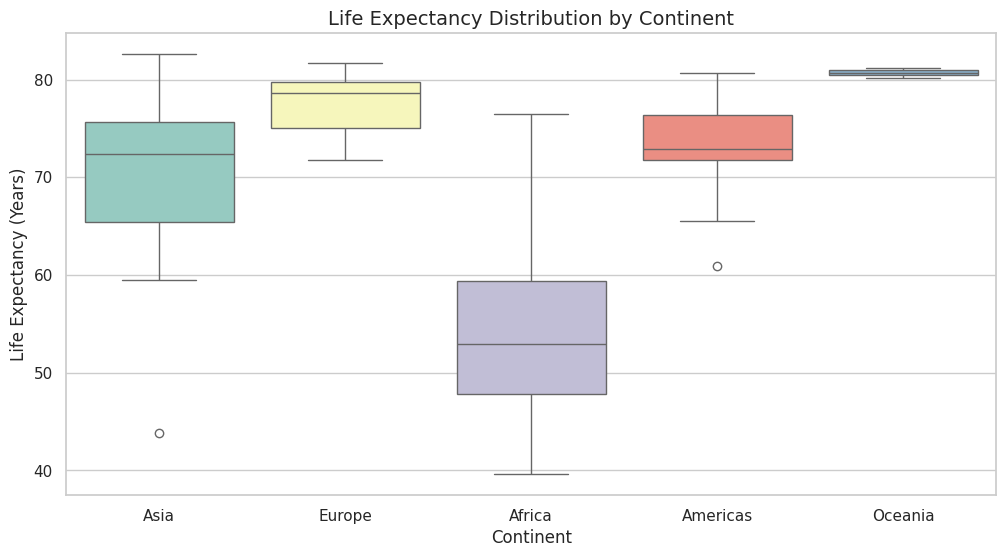

In [12]:
plt.figure(figsize=(12, 6))

# Boxplot: Life Expectancy by Continent
sns.boxplot(data=df, x='continent', y='life_exp', palette='Set3')

plt.title('Life Expectancy Distribution by Continent', fontsize=14)
plt.ylabel('Life Expectancy (Years)')
plt.xlabel('Continent')
plt.show()

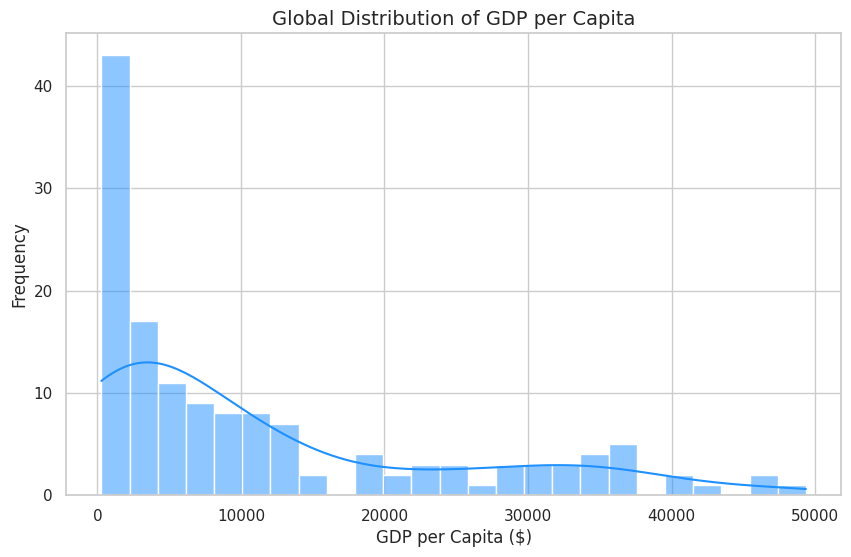

In [13]:
plt.figure(figsize=(10, 6))

# Histogram with KDE (Kernel Density Estimate)
sns.histplot(df['gdp_cap'], bins=25, kde=True, color='dodgerblue')

plt.title('Global Distribution of GDP per Capita', fontsize=14)
plt.xlabel('GDP per Capita ($)')
plt.ylabel('Frequency')
plt.show()

/tmp/ipython-input-1222512734.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




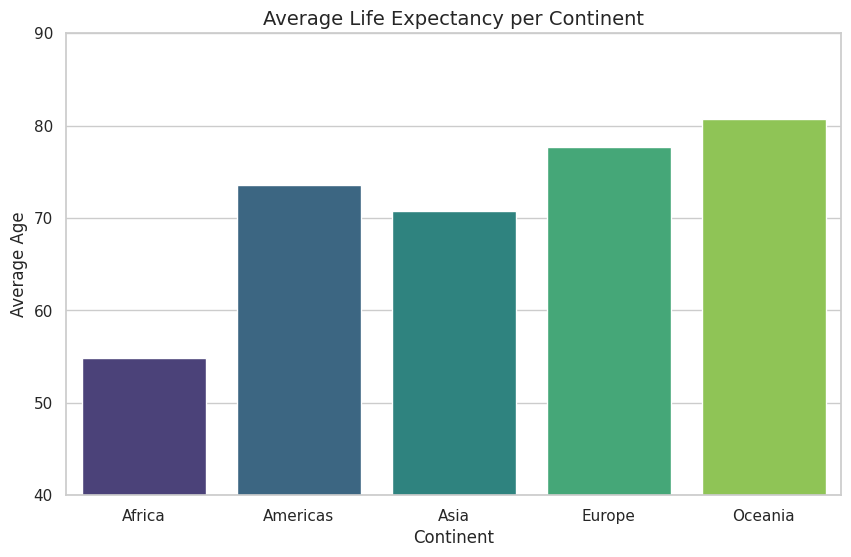

In [14]:
# Calculate average life expectancy per continent
avg_life_exp = df.groupby('continent')['life_exp'].mean().reset_index()

plt.figure(figsize=(10, 6))
# Barplot
sns.barplot(data=avg_life_exp, x='continent', y='life_exp', palette='viridis')

plt.ylim(40, 90) # Adjust Y-axis for better visibility
plt.title('Average Life Expectancy per Continent', fontsize=14)
plt.ylabel('Average Age')
plt.xlabel('Continent')
plt.show()

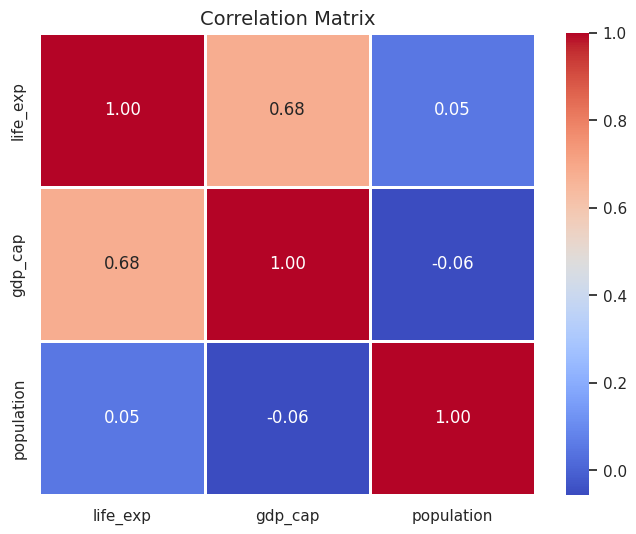

In [15]:
plt.figure(figsize=(8, 6))

# Correlation matrix for numerical columns
corr = df[['life_exp', 'gdp_cap', 'population']].corr()

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title('Correlation Matrix', fontsize=14)
plt.show()

In [16]:
# Interactive Scatter Plot
fig = px.scatter(df,
                 x="gdp_cap",
                 y="life_exp",
                 size="population",
                 color="continent",
                 hover_name="country",
                 log_x=True,
                 size_max=60,
                 title="Gapminder 2007: GDP vs Life Expectancy (Interactive)",
                 template="plotly_white")

fig.show()